# OT-CFM — Hold-One-Out Evaluation on the EB Dataset

Same LOO experiment as `2.01.05` (MIOFlow), using **Optimal-Transport Conditional Flow Matching (OT-CFM)**.

**Benchmarking design:**
- GAGA is MIOFlow's novelty — CFM should not benefit from it
- OT-CFM trains **directly in raw PCA space (50D)**, no GAGA encoding
- GAGA is used **only for 2D visualisation** (encode predicted PCA → GAGA 2D for scatter plots)
- Metrics (W1, MMD-G, MMD-M) computed in **PCA 50D** — same space as MIOFlow's decoded output

In [18]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import ot

sys.path.append('/Users/joaofelipe/Yale/Omics Toolbox/4_Code/MIOFlow_baselines/conditional-flow-matching')
from torchcfm.conditional_flow_matching import ExactOptimalTransportConditionalFlowMatcher
from torchcfm.models import MLP
from torchcfm.utils import torch_wrapper
from torchdyn.core import NeuralODE
from tqdm import tqdm

from mioflow import fit_gaga

## 1. Load Data

In [19]:
adata = sc.read_h5ad('data/scRNAseq/preprocessed_eb_adata.h5ad')
time_column = 'time_bin'
sorted_bins = sorted(adata.obs[time_column].unique())
print(adata)
print(f"Time bins: {sorted_bins}")

AnnData object with n_obs × n_vars = 16826 × 17845
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'pca', 'timepoint_colors'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'
Time bins: [0.0, 1.0, 2.0, 3.0, 4.0]


## 2. Train GAGA (on all data)

Identical to `2.01.05` — train once and reuse across all LOO folds.

In [20]:
gaga_model = fit_gaga(
    X_pca      = adata.obsm['X_pca'],
    X_phate    = adata.obsm['X_phate'],
    latent_dim = 2,
    hidden_dims= [128, 64],
    batch_size = 1024,
    encoder_epochs=300,
    decoder_epochs=300,
    learning_rate=1e-3,
)

GAGA architecture: 50 → 2
Phase 1: Training encoder (decoder frozen) for distance preservation
Training GAGA on device: cpu
Encoder frozen: False, Decoder frozen: True
Reconstruction weight: 0.0, Distance weight: 1.0


Epochs: 100%|██████████| 300/300 [01:30<00:00,  3.32it/s, train_loss=0.0065, recon=1.0313, dist=0.0065]



Phase 2: Training decoder (encoder frozen) for reconstruction
Training GAGA on device: cpu
Encoder frozen: True, Decoder frozen: False
Reconstruction weight: 1.0, Distance weight: 0.0


Epochs: 100%|██████████| 300/300 [00:52<00:00,  5.72it/s, train_loss=0.7550, recon=0.7550, dist=0.0062]


### GAGA sanity check

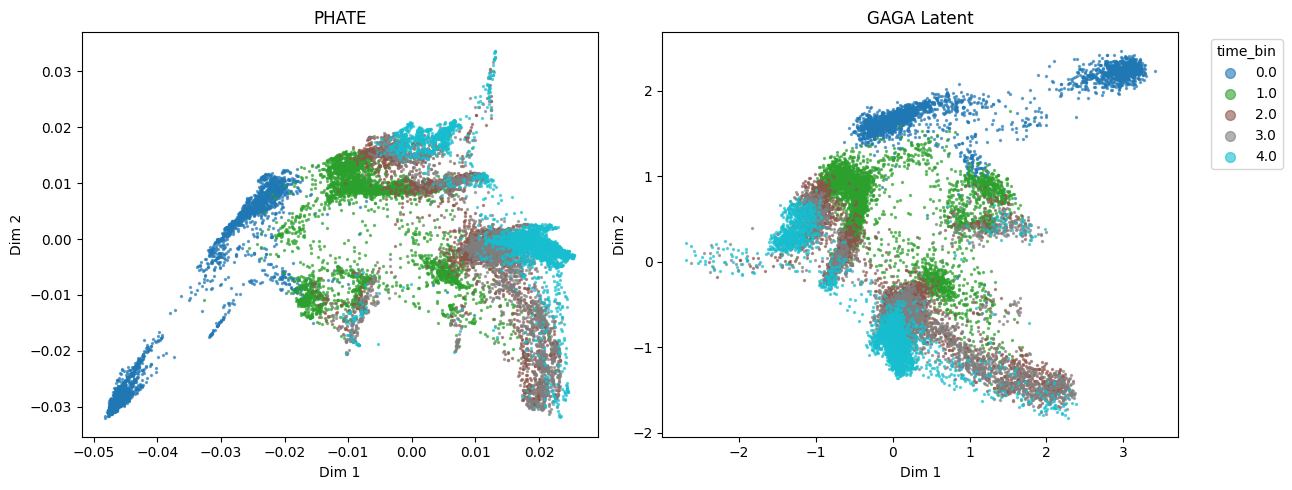

In [21]:
X_pca_all = adata.obsm['X_pca'].astype('float32')
X_pca_all_scaled = gaga_model.input_scaler.transform(X_pca_all)
gaga_model.eval()
with torch.no_grad():
    gaga_embeddings = gaga_model.encode(torch.tensor(X_pca_all_scaled)).numpy()
adata.obsm['X_gaga'] = gaga_embeddings

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
categories = adata.obs[time_column].astype('category').cat
codes, cat_names = categories.codes.values, categories.categories
colors = plt.cm.tab10(np.linspace(0, 1, len(cat_names)))
for ax, key, title in zip(axes, ['X_phate', 'X_gaga'], ['PHATE', 'GAGA Latent']):
    for i, name in enumerate(cat_names):
        mask = codes == i
        ax.scatter(adata.obsm[key][mask, 0], adata.obsm[key][mask, 1],
                   color=colors[i], s=2, alpha=0.6, label=name)
    ax.set_title(title); ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
axes[-1].legend(title=time_column, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
plt.tight_layout(); plt.show()

## 3. OT-CFM helpers

### 3.1 Build training dataset for one LOO fold

In [22]:
def build_cfm_dataset(adata_full, gaga_model, heldout_bin, time_column):
    """
    Encode all cells except heldout_bin into normalised GAGA 2D latent space.

    Returns X_list (one normalised 2D array per training timepoint),
    mean_, std_, and training_bins.
    """
    adata_train = adata_full[adata_full.obs[time_column] != heldout_bin]
    X_pca = adata_train.obsm['X_pca'].astype('float32')
    X_pca_scaled = gaga_model.input_scaler.transform(X_pca)
    gaga_model.eval()
    with torch.no_grad():
        X_gaga = gaga_model.encode(torch.tensor(X_pca_scaled)).numpy().astype('float32')

    mean_ = X_gaga.mean(axis=0)
    std_  = X_gaga.std(axis=0); std_[std_ == 0] = 1.0
    gaga_norm = ((X_gaga - mean_) / std_).astype('float32')

    training_bins = [b for b in sorted(adata_full.obs[time_column].unique()) if b != heldout_bin]
    time_labels = pd.factorize(adata_train.obs[time_column], sort=True)[0]
    X_list = [gaga_norm[time_labels == i] for i in range(len(training_bins))]
    return X_list, mean_, std_, training_bins

### 3.2 Training loop

In [23]:
def get_batch_cfm(FM, X_list, batch_size, device):
    """Sample a training batch across all consecutive intervals (time-shifted t)."""
    ts, xts, uts = [], [], []
    for t_start in range(len(X_list) - 1):
        i0 = np.random.choice(len(X_list[t_start]),     size=batch_size)
        i1 = np.random.choice(len(X_list[t_start + 1]), size=batch_size)
        x0 = torch.tensor(X_list[t_start][i0],     dtype=torch.float32, device=device)
        x1 = torch.tensor(X_list[t_start + 1][i1], dtype=torch.float32, device=device)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        ts.append(t + t_start)   # shift to [t_start, t_start+1]
        xts.append(xt)
        uts.append(ut)
    return torch.cat(ts), torch.cat(xts), torch.cat(uts)


def train_cfm_fold(X_list, n_iters=10000, hidden_dim=64, sigma=0.1,
                   lr=1e-4, batch_size=128, device='cpu', verbose=False):
    """Train OT-CFM on X_list (list of normalised latent arrays per timepoint)."""
    dim = X_list[0].shape[1]
    model = MLP(dim=dim, time_varying=True, w=hidden_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

    losses = []
    pbar = tqdm(range(n_iters), desc='OT-CFM', disable=not verbose)
    for i in pbar:
        optimizer.zero_grad()
        t, xt, ut = get_batch_cfm(FM, X_list, batch_size, device)
        vt = model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if verbose and i % 1000 == 0:
            pbar.set_postfix(loss=f'{loss.item():.4f}')

    return model, losses

### 3.3 Prediction at held-out timepoint

In [24]:
def predict_at_heldout_cfm(cfm_model, X_list, mean_, std_,
                            adata_full, gaga_model, heldout_bin,
                            time_column, device='cpu', n_steps=200,
                            n_trajectories=None, seed=42):
    """
    Integrate OT-CFM from label_prev → t_label_heldout in GAGA 2D space.

    Returns
    -------
    pred_latent : (n, 2)  — predicted GAGA 2D positions (for metrics + visualisation)
    true_latent : (m, 2)  — ground-truth GAGA 2D positions (for metrics + visualisation)
    """
    all_bins = sorted(adata_full.obs[time_column].unique())
    heldout_idx = all_bins.index(heldout_bin)
    t_prev, t_next = all_bins[heldout_idx - 1], all_bins[heldout_idx + 1]

    frac = (heldout_bin - t_prev) / (t_next - t_prev)
    training_bins = [b for b in all_bins if b != heldout_bin]
    label_prev      = float(training_bins.index(t_prev))
    label_next      = float(training_bins.index(t_next))
    t_label_heldout = label_prev + frac * (label_next - label_prev)

    X_prev_arr = X_list[int(label_prev)]
    if n_trajectories is not None and n_trajectories < len(X_prev_arr):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(X_prev_arr), size=n_trajectories, replace=False)
        X_prev_arr = X_prev_arr[idx]
    X_prev = torch.tensor(X_prev_arr, dtype=torch.float32)
    t_span = torch.linspace(label_prev, t_label_heldout, n_steps)

    node = NeuralODE(torch_wrapper(cfm_model), solver='euler', sensitivity='adjoint')
    cfm_model.eval()
    with torch.no_grad():
        traj = node.trajectory(X_prev.to(device), t_span=t_span.to(device)).cpu()

    pred_latent = (traj[-1].numpy() * std_ + mean_).astype('float32')  # denormalise → GAGA 2D

    # Ground truth: encode PCA → GAGA 2D
    mask_held = adata_full.obs[time_column] == heldout_bin
    X_pca_held = adata_full.obsm['X_pca'][mask_held.values].astype('float32')
    X_pca_held_scaled = gaga_model.input_scaler.transform(X_pca_held)
    gaga_model.eval()
    with torch.no_grad():
        true_latent = gaga_model.encode(torch.tensor(X_pca_held_scaled)).numpy().astype('float32')

    return pred_latent, true_latent

## 4. Evaluation metrics (PCA space)

Identical definitions to `2.01.05`.

In [25]:
def wasserstein1(X, Y, n_sample=1000, seed=42):
    rng = np.random.default_rng(seed)
    ix = rng.choice(len(X), size=min(n_sample, len(X)), replace=False)
    iy = rng.choice(len(Y), size=min(n_sample, len(Y)), replace=False)
    Xs, Ys = X[ix], Y[iy]
    M = ot.dist(Xs, Ys, metric='euclidean')
    return float(ot.emd2(ot.unif(len(Xs)), ot.unif(len(Ys)), M))

def _gaussian_kernel(X, Y, sigma):
    sq = np.sum((X[:, None] - Y[None]) ** 2, axis=-1)
    return np.exp(-sq / (2 * sigma ** 2))

def mmd_gaussian(X, Y):
    XY = np.vstack([X, Y])
    M  = ot.dist(XY, XY, metric='euclidean')
    sigma = float(np.median(M[M > 0])) or 1.0
    return float(_gaussian_kernel(X,X,sigma).mean()
                 + _gaussian_kernel(Y,Y,sigma).mean()
                 - 2*_gaussian_kernel(X,Y,sigma).mean())

def mmd_mean(X, Y):
    return float(np.linalg.norm(X.mean(axis=0) - Y.mean(axis=0)))

def compute_metrics(pred_pca, true_pca):
    return {
        'W1':    wasserstein1(pred_pca, true_pca),
        'MMD_G': mmd_gaussian(pred_pca, true_pca),
        'MMD_M': mmd_mean(pred_pca, true_pca),
    }

print("Metric functions ready.")

Metric functions ready.


## 5. Focal experiment — hold out timepoint 2

In [26]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
FOCAL_BIN = sorted_bins[1]
print(f"Holding out time bin: {FOCAL_BIN}  |  device: {DEVICE}")

X_list_focal, mean_focal, std_focal, training_bins_focal = build_cfm_dataset(
    adata, gaga_model, FOCAL_BIN, time_column
)
print(f"Training bins: {training_bins_focal}")
print(f"GAGA 2D dims: {X_list_focal[0].shape[1]}  |  Cells per bin: {[len(x) for x in X_list_focal]}")

Holding out time bin: 1.0  |  device: cpu
Training bins: [0.0, 2.0, 3.0, 4.0]
GAGA 2D dims: 2  |  Cells per bin: [2381, 3279, 3668, 3333]


OT-CFM: 100%|██████████| 10000/10000 [00:42<00:00, 234.81it/s, loss=0.1179]


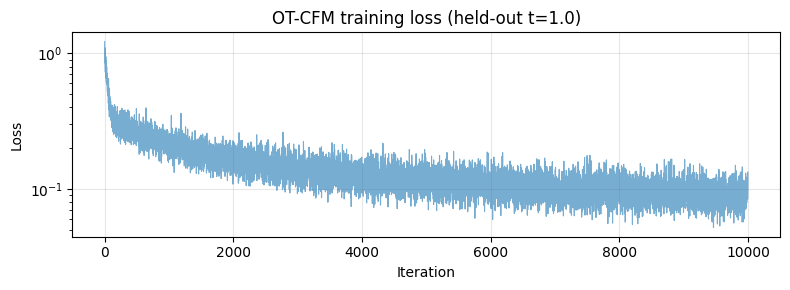

In [27]:
cfm_focal, losses_focal = train_cfm_fold(
    X_list_focal,
    n_iters=10000,
    hidden_dim=64,
    sigma=0.1,
    lr=1e-4,
    batch_size=128,
    device=DEVICE,
    verbose=True,
)

plt.figure(figsize=(8, 3))
plt.plot(losses_focal, alpha=0.6, linewidth=0.8)
plt.yscale('log'); plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title(f'OT-CFM training loss (held-out t={FOCAL_BIN})')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [28]:
pred_focal_latent, true_focal_latent = predict_at_heldout_cfm(
    cfm_focal, X_list_focal, mean_focal, std_focal,
    adata, gaga_model, FOCAL_BIN, time_column, device=DEVICE,
    n_trajectories=100,
)
print(f"Predicted  — latent: {pred_focal_latent.shape}")
print(f"Ground truth — latent: {true_focal_latent.shape}")

Predicted  — latent: (100, 2)
Ground truth — latent: (4165, 2)


### 5.1 Interpolation plot — predicted vs. ground truth at timepoint 2

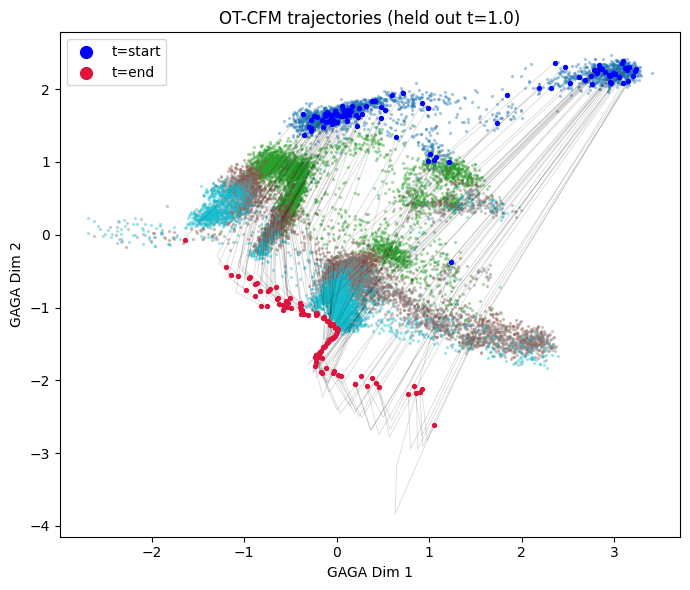

In [29]:
from torchdyn.core import NeuralODE
from torchcfm.utils import torch_wrapper

# Full trajectory: integrate from label 0 → last training label
n_training = len(training_bins_focal)
t_span_full = torch.arange(n_training, dtype=torch.float32)  # [0, 1, 2, 3]

idx = np.random.choice(len(X_list_focal[0]), size=100, replace=False)
X_start = torch.tensor(X_list_focal[0][idx], dtype=torch.float32)

node = NeuralODE(torch_wrapper(cfm_focal), solver='euler', sensitivity='adjoint')
cfm_focal.eval()
with torch.no_grad():
    traj_norm = node.trajectory(X_start, t_span=t_span_full).cpu().numpy()
# traj_norm: (n_time_steps, 100, 2) — normalised GAGA 2D

# Denormalise → GAGA 2D (no encoding needed — already in GAGA space)
traj_gaga = np.stack([
    (traj_norm[i] * std_focal + mean_focal).astype('float32')
    for i in range(traj_norm.shape[0])
])  # (n_steps, 100, 2)

fig, ax = plt.subplots(figsize=(7, 6))
palette = plt.cm.tab10(np.linspace(0, 1, len(sorted_bins)))
for i, tb in enumerate(sorted_bins):
    mask = adata.obs[time_column] == tb
    ax.scatter(adata.obsm['X_gaga'][mask, 0], adata.obsm['X_gaga'][mask, 1],
               color=palette[i], s=2, alpha=0.3, rasterized=True)

for j in range(traj_gaga.shape[1]):
    ax.plot(traj_gaga[:, j, 0], traj_gaga[:, j, 1],
            color='black', alpha=0.15, linewidth=0.6)

ax.scatter(traj_gaga[0,  :, 0], traj_gaga[0,  :, 1], color='blue',    s=8, zorder=5, label='t=start')
ax.scatter(traj_gaga[-1, :, 0], traj_gaga[-1, :, 1], color='crimson', s=8, zorder=5, label='t=end')

ax.set_title(f'OT-CFM trajectories (held out t={FOCAL_BIN})')
ax.set_xlabel('GAGA Dim 1'); ax.set_ylabel('GAGA Dim 2')
ax.legend(markerscale=3); plt.tight_layout(); plt.show()

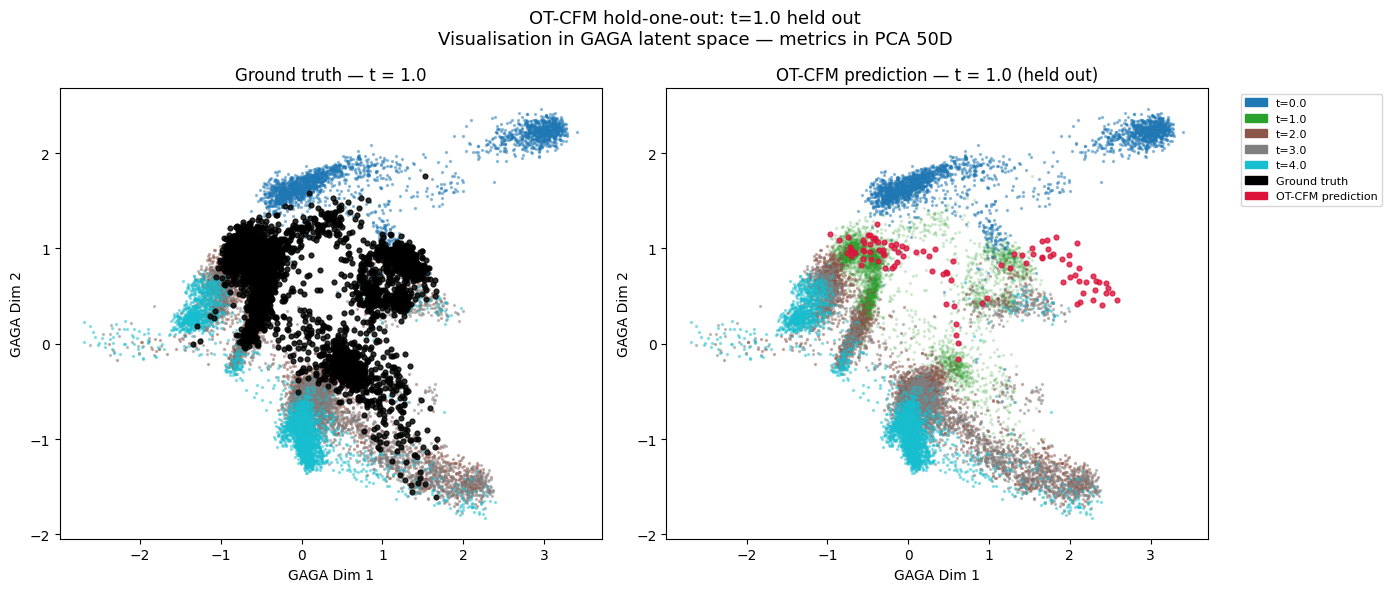

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = plt.cm.tab10(np.linspace(0, 1, len(sorted_bins)))

for ax in axes:
    for i, tb in enumerate(sorted_bins):
        mask = adata.obs[time_column] == tb
        alpha = 0.15 if tb == FOCAL_BIN else 0.4
        ax.scatter(adata.obsm['X_gaga'][mask, 0], adata.obsm['X_gaga'][mask, 1],
                   color=palette[i], s=2, alpha=alpha, rasterized=True)

axes[0].scatter(true_focal_latent[:, 0], true_focal_latent[:, 1],
                color='black', s=12, alpha=0.8, zorder=5)
axes[0].set_title(f'Ground truth — t = {FOCAL_BIN}')
axes[0].set_xlabel('GAGA Dim 1'); axes[0].set_ylabel('GAGA Dim 2')

axes[1].scatter(pred_focal_latent[:, 0], pred_focal_latent[:, 1],
                color='crimson', s=12, alpha=0.8, zorder=5)
axes[1].set_title(f'OT-CFM prediction — t = {FOCAL_BIN} (held out)')
axes[1].set_xlabel('GAGA Dim 1'); axes[1].set_ylabel('GAGA Dim 2')

handles = [mpatches.Patch(color=palette[i], label=f't={tb}') for i, tb in enumerate(sorted_bins)]
handles += [mpatches.Patch(color='black', label='Ground truth'),
            mpatches.Patch(color='crimson', label='OT-CFM prediction')]
axes[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.suptitle(f'OT-CFM hold-one-out: t={FOCAL_BIN} held out\n'
             'Visualisation in GAGA latent space — metrics in PCA 50D', fontsize=13)
plt.tight_layout(); plt.show()

### 5.2 Metrics for held-out timepoint 2

In [31]:
metrics_focal = compute_metrics(pred_focal_latent, true_focal_latent)
df_focal = pd.DataFrame([{'Held-out t': FOCAL_BIN, **metrics_focal}])
print(df_focal.to_string(index=False))
df_focal

 Held-out t       W1    MMD_G    MMD_M
        1.0 0.792368 0.144238 0.770941


,Held-out t,W1,MMD_G,MMD_M
0,1.0,0.792368,0.144238,0.770941


## 6. Full Leave-One-Out Table

In [33]:
N_TRAJ = 100  # fixed seed population for comparability across methods

loo_results = []

for heldout_bin in sorted_bins[1:-1]:
    print(f"\n{'='*50}\n  LOO fold: t={heldout_bin}\n{'='*50}")

    if heldout_bin == FOCAL_BIN:
        pred_latent, true_latent = pred_focal_latent, true_focal_latent
    else:
        X_list, mean_, std_, _ = build_cfm_dataset(adata, gaga_model, heldout_bin, time_column)
        cfm_model, _ = train_cfm_fold(
            X_list, n_iters=10000, hidden_dim=64, sigma=0.1,
            lr=1e-4, batch_size=128, device=DEVICE, verbose=False,
        )
        pred_latent, true_latent = predict_at_heldout_cfm(
            cfm_model, X_list, mean_, std_,
            adata, gaga_model, heldout_bin, time_column, device=DEVICE,
            n_trajectories=N_TRAJ,
        )

    metrics = compute_metrics(pred_latent, true_latent)
    loo_results.append({'t': heldout_bin, **metrics})
    print(f"  W1={metrics['W1']:.4f}  MMD-G={metrics['MMD_G']:.4f}  MMD-M={metrics['MMD_M']:.4f}")

df_loo = pd.DataFrame(loo_results)
print("\nDone.")
df_loo


  LOO fold: t=1.0
  W1=0.7924  MMD-G=0.1442  MMD-M=0.7709

  LOO fold: t=2.0
  W1=0.4741  MMD-G=0.0296  MMD-M=0.2034

  LOO fold: t=3.0
  W1=0.4612  MMD-G=0.0299  MMD-M=0.4343

Done.


,t,W1,MMD_G,MMD_M
0,1.0,0.792368,0.144238,0.770941
1,2.0,0.474137,0.029559,0.203435
2,3.0,0.461246,0.029911,0.434304


### Summary table — LOO W1 and MMD (OT-CFM, α-decay kernel)

In [34]:
df_display = df_loo.copy()
df_display.columns = ['Held-out t', 'W1', 'MMD (G)', 'MMD (M)']
df_display = df_display.set_index('Held-out t')
df_display.loc['Mean'] = df_display.mean()

df_display.style \
    .format('{:.4f}') \
    .set_caption('Leave-one-out W1 and MMD — OT-CFM (EB dataset, α-decay kernel)') \
    .highlight_min(color='#d4efdf', axis=0, subset=pd.IndexSlice[df_display.index[:-1], :]) \
    .highlight_max(color='#fadbd8', axis=0, subset=pd.IndexSlice[df_display.index[:-1], :])

,W1,MMD (G),MMD (M)
Held-out t,,,
1.000000,0.7924,0.1442,0.7709
2.000000,0.4741,0.0296,0.2034
3.000000,0.4612,0.0299,0.4343
Mean,0.5759,0.0679,0.4696


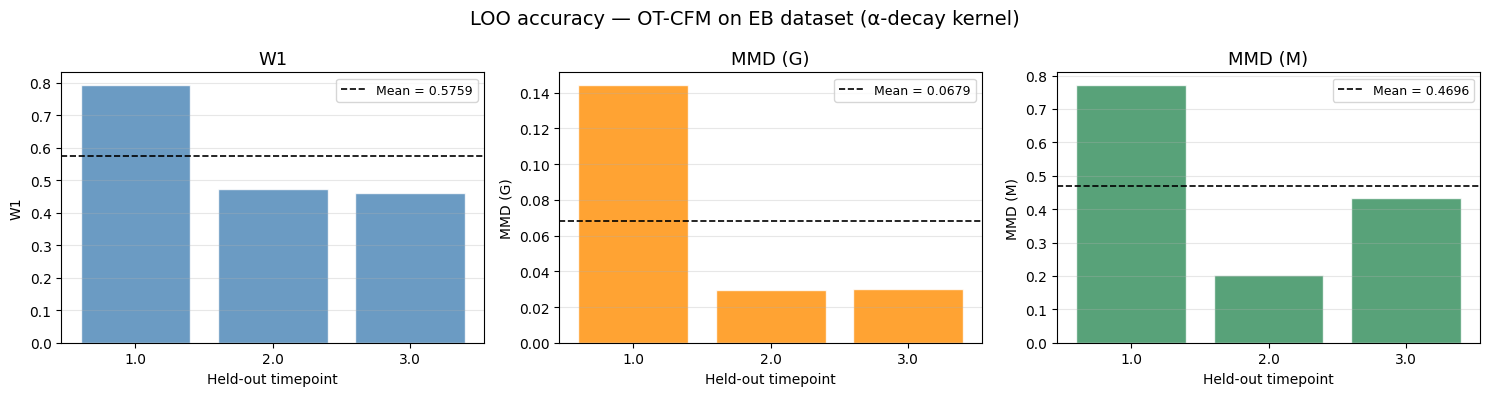

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, col, label, color in zip(
    axes,
    ['W1', 'MMD_G', 'MMD_M'],
    ['W1', 'MMD (G)', 'MMD (M)'],
    ['steelblue', 'darkorange', 'seagreen'],
):
    vals = df_loo[col].values
    ts   = df_loo['t'].astype(str).values
    ax.bar(ts, vals, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean = {vals.mean():.4f}')
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Held-out timepoint')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('LOO accuracy — OT-CFM on EB dataset (α-decay kernel)', fontsize=14)
plt.tight_layout()
plt.show()